<a href="https://colab.research.google.com/github/aiaaee/Forward-Kinematics-Prediction-of-KUKA-LBR-iiwa/blob/main/KUKA_iiwa_Robot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Project Name: Forward Kinematics Prediction of KUKA LBR iiwa

### Robot Name: KUKA LBR iiwa
### Author : Amin Alaee

In [ ]:
!pip install pybullet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.5/80.5 MB 12.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [2]:
import pybullet as p
import pybullet_data
import matplotlib
import numpy as np
import imageio
from IPython.display import Video , display
import matplotlib.pyplot as plt
import os
import pandas as pd

## Load a Robot from URDF

In [3]:
np.random.seed(42)

In [4]:
physics_client = p.connect(p.DIRECT)

In [5]:
p.setAdditionalSearchPath(
    pybullet_data.getDataPath()
)

In [6]:
robot = p.loadURDF("kuka_iiwa/model.urdf" , useFixedBase=True)

In [7]:
num_joints = p.getNumJoints(robot)
num_joints

7

In [8]:
for i in range(num_joints):
  info = p.getJointInfo(robot , i)
  print(i , info[1].decode())

0 lbr_iiwa_joint_1
1 lbr_iiwa_joint_2
2 lbr_iiwa_joint_3
3 lbr_iiwa_joint_4
4 lbr_iiwa_joint_5
5 lbr_iiwa_joint_6
6 lbr_iiwa_joint_7


In [9]:
end_effector = p.getLinkState(robot , 6)
print(end_effector[0])

(1.481887826451083e-13, 2.4091388606262143e-12, 1.2810000000000001)


In [10]:
for i in range(num_joints):
  state = p.getLinkState(robot , i)
  position = state[0]
  print(f"Link {i}: {position}")

Link 0: (0.0, -0.03, 0.27749999999999997)
Link 1: (-0.00030000000000868655, 0.041999999999711046, 0.41900000000020565)
Link 2: (2.068234906255073e-14, 0.029999999998998647, 0.6945)
Link 3: (6.545955175194354e-14, -0.03400000000067328, 0.8470000000001665)
Link 4: (-9.999999989286561e-05, -0.0209999999993537, 1.0405000000002058)
Link 5: (1.272582842055947e-13, 0.00040000000201545136, 1.180599999999998)
Link 6: (1.481887826451083e-13, 2.4091388606262143e-12, 1.2810000000000001)


## Robot Visualization

In [11]:
view_matrix = p.computeViewMatrix(
    cameraEyePosition=[2.0 , 1 , 1] ,
    cameraTargetPosition=[0,0,0.5] ,
    cameraUpVector=[0 , 0 , 1]
)

projection_matrix = p.computeProjectionMatrixFOV(
    fov = 60 ,
    aspect= 1,
    nearVal=0.1 ,
    farVal=100
)

width, height, rgb, depth, seg = p.getCameraImage(
    width=800,
    height=800,
    viewMatrix=view_matrix,
    projectionMatrix=projection_matrix
)

def take_photo(robot, view_matrix, projection_matrix, width=500, height=500):
    _, _, rgb, _, _ = p.getCameraImage(
        width=width,
        height=height,
        viewMatrix=view_matrix,
        projectionMatrix=projection_matrix
    )
    image = np.reshape(rgb, (height, width, 4))[:, :, :3]
    return image

def move_robot(q):
  for i in range(7):
    p.resetJointState(robot , i , q[i])
  return p.getLinkState(robot , 6)[0]

def set_joint_angles(robot , angles):
  for i , angle in enumerate(angles):
    p.resetJointState(robot , i , angle)

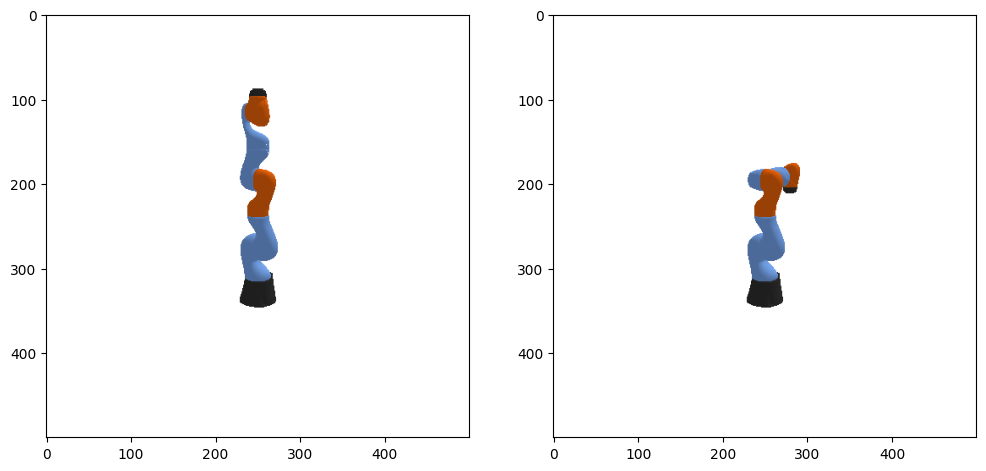

In [12]:
angles_1 = [0,0,0,0,0,0,0]
angles_2 = [0 , 0 , 0 , 1.57 , 0 , -1.57 , 0]

fig , (ax1 , ax2) = plt.subplots(1 , 2 , figsize=(12,6))

set_joint_angles(robot , angles_1)
img1 = take_photo(robot , view_matrix , projection_matrix)

set_joint_angles(robot , angles_2)
img2 = take_photo(robot , view_matrix , projection_matrix)

ax1.imshow(img1)
ax2.imshow(img2)

## Extract Joint Limits & End-Effector Positions

In [13]:
def forward_kinematics(joint_angles):
  for i in range(7):
    p.resetJointState(robot , i , joint_angles[i])
  position = p.getLinkState(robot , 6 , computeForwardKinematics=True)
  return position

In [14]:
joint_limits = []
for i in range(7):
  info = p.getJointInfo(robot , i)
  joint_limits.append((info[8] , info[9]))

In [15]:
def random_configuration():
  q = []
  for low , high in joint_limits:
    q.append(np.random.uniform(low , high))
  return q

In [18]:
points = []
orientations = []
for _ in range(10000) :
  q = random_configuration()
  points.append(xyz)
  orientations.append(orn)

In [19]:
points = np.array(points)
orientations = np.array(orientations)
xs = points[: , 0]
ys = points[: , 1]
zs = points[: , 2]

In [20]:
xs.shape , ys.shape , zs.shape

((10000,), (10000,), (10000,))

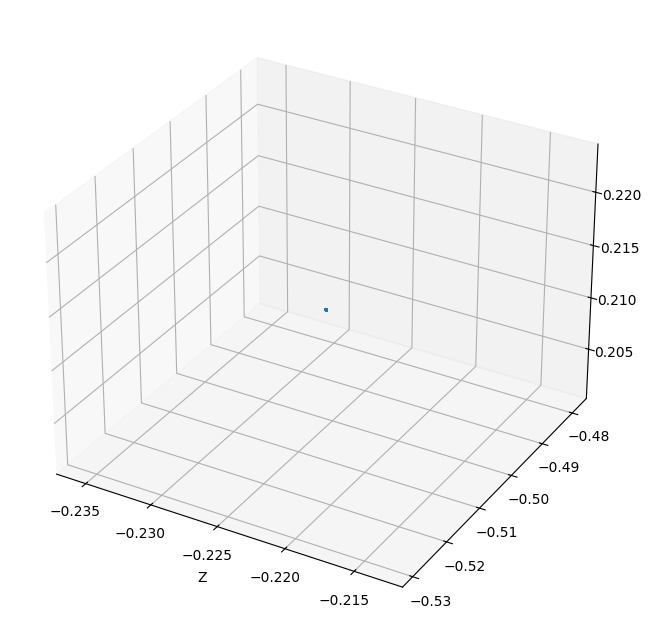

In [21]:
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111 , projection='3d')
ax.scatter(xs , ys , zs , s=2 , alpha=0.5)


ax.set_xlabel("X")
ax.set_xlabel("Y")
ax.set_xlabel("Z")
plt.show()

In [22]:
dataset = []

for _ in range(10000):
  q = random_configuration()
  x ,  y , z = forward_kinematics(q)[0]

  dataset.append([
      *q , x , y , z
  ])

In [23]:
columns = ['q1' , 'q2' , 'q3' , 'q4' , 'q5' , 'q6' , 'q7' , 'X' , 'Y' , 'Z']
df = pd.DataFrame(dataset , columns=columns)

In [24]:
df.head()

,q1,q2,q3,q4,q5,q6,q7,X,Y,Z
0,-2.205594,1.150757,0.687245,0.617608,-1.508887,0.455022,1.520704,-0.570587,-0.415378,0.868396
1,-1.124737,1.872321,-0.733617,-0.590998,-0.681451,1.688314,-1.178301,0.054546,-0.658910,-0.006440
2,0.674333,-0.988896,1.636789,2.046064,2.811623,-1.598001,1.901635,0.060319,-0.456072,0.586749
3,0.875620,1.074150,-0.701521,-0.638272,-0.392089,2.081719,-2.061057,0.580772,0.379792,0.506077
4,2.486889,0.160019,0.944657,-1.725151,1.947199,-1.719547,1.124840,-0.423750,0.011046,0.633388


In [25]:
df.to_csv('IKRobot.csv')

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   q1      10000 non-null  float64
 1   q2      10000 non-null  float64
 2   q3      10000 non-null  float64
 3   q4      10000 non-null  float64
 4   q5      10000 non-null  float64
 5   q6      10000 non-null  float64
 6   q7      10000 non-null  float64
 7   X       10000 non-null  float64
 8   Y       10000 non-null  float64
 9   Z       10000 non-null  float64
dtypes: float64(10)
memory usage: 781.4 KB


In [27]:
df.describe()

,q1,q2,q3,q4,q5,q6,q7,X,Y,Z
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,0.044589,-0.002992,0.007384,0.001173,-0.002427,-0.002066,0.002622,0.003178,0.000217,0.607523
std,1.702419,1.210642,1.725577,1.210059,1.710775,1.213093,1.754405,0.402858,0.416563,0.368140
min,-2.965580,-2.094368,-2.966272,-2.094242,-2.966469,-2.094285,-3.054297,-0.891057,-0.905137,-0.324474
25%,-1.411341,-1.046868,-1.498321,-1.047187,-1.503457,-1.064488,-1.512942,-0.319883,-0.335315,0.332265
50%,0.078461,-0.009012,0.029461,-0.015034,-0.017316,-0.002330,-0.006580,0.003398,-0.001575,0.648335
75%,1.521692,1.054956,1.476093,1.045217,1.486997,1.048199,1.500535,0.323522,0.333214,0.903025
max,2.966530,2.094324,2.965949,2.094351,2.966195,2.094302,3.054174,0.917529,0.903546,1.280526


In [28]:
set_joint_angles(robot , angles_1)
img1 = take_photo(robot , view_matrix , projection_matrix)

In [ ]:
angles_sample = []
x= df.loc[1 , ['q1' , 'q2' , 'q3' , 'q4' , 'q5' , 'q6']]
for i in x :
  angles_sample.append(i)

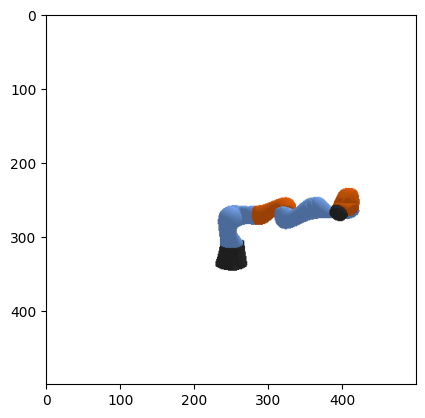

In [ ]:
set_joint_angles(robot , angles_sample)
img1 = take_photo(robot , view_matrix , projection_matrix)
plt.imshow(img1)